# Giai đoạn 7 — Xây dựng đặc trưng (Feature Engineering)

Chuyển dữ liệu thô thành ma trận số để XGBoost huấn luyện, đồng thời **đảm bảo không có đặc trưng
nào suy ra được từ nhãn cần dự đoán**.

## Nguyên tắc quan trọng nhất: không đưa khối ngành vào đặc trưng

Khối ngành **suy trực tiếp từ nhãn ngành** (`ma_khoi = NGANH_TO_KHOI[ma_nganh]`). Nếu đưa 7 cột
one-hot khối ngành vào đặc trưng, ta đang **mách trước cho mô hình 1/7 đáp án** — thu hẹp bài toán
39 lớp xuống chỉ còn 2–14 lớp. Chỉ số sẽ đẹp giả tạo, và tệ hơn: lúc chạy thật cột này phải lấy từ
dự đoán của Tầng 1 (vốn sai khoảng một nửa), gây **lệch giữa lúc huấn luyện và lúc phục vụ**.

**Giải pháp:** Tầng 1 và Tầng 2 dùng **chung một bộ đặc trưng gốc**, không có gì liên quan tới nhãn.
Cấu trúc phân cấp được áp dụng lúc **suy diễn** ở Giai đoạn 8 bằng cách nhân xác suất:

$$P(\text{ngành}) \;\propto\; P_{\text{Tầng 2}}(\text{ngành}) \times P_{\text{Tầng 1}}(\text{khối của ngành})^{\beta}$$

Cách này có **rò rỉ bằng 0** và **train khớp hoàn toàn với serve**.

## Hai cải tiến về chất lượng đặc trưng

**1. Chuẩn hoá điểm theo môn (z-score).** Điểm trung bình 3 môn thô không so sánh được:
8.0 của tổ hợp A00 (Toán–Lý–Hoá) và 8.0 của C00 (Văn–Sử–Địa) mang ý nghĩa khác nhau vì mặt bằng
điểm từng môn khác nhau. Chuẩn hoá z-score theo từng môn (dùng thống kê **chỉ tính trên tập train**)
rồi mới lấy trung bình các môn đã thi.

**2. Thêm đặc trưng "nhóm tổ hợp".** Tám tổ hợp chỉ xuất hiện ở khảo sát mà không có ở TTTH.
Bổ sung nhóm Tự nhiên / Xã hội / Hỗn hợp giúp mô hình khái quát hoá được sang các tổ hợp hiếm này.

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ── Thiết lập kiểu biểu đồ dùng chung cho toàn bộ báo cáo ────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

# Bảng màu thống nhất
C_THAT  = "#D64550"   # dữ liệu thật
C_GA    = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH  = "#3B7DD8"   # nhấn mạnh chính
C_CAM   = "#E8873A"   # nhấn mạnh phụ
C_TIM   = "#8E5FBF"
C_XAM   = "#AEB6BF"   # nền / mốc so sánh
C_DAM   = "#2C3E50"
C_KHOI  = ["#3B7DD8", "#E8873A", "#8E5FBF", "#19A2A2", "#D64550", "#C9A227", "#5D6D7E"]


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    # Ghi số ở cuối mỗi thanh ngang
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    # Ghi số trên đầu mỗi cột dọc
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=-0.02):
    # Dòng chú giải nằm dưới hình — nêu kết luận rút ra từ biểu đồ
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def luu(fig, thu_muc, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 Đã lưu hình: {ten}")

SPLIT_DIR  = Path("../data/processed/02_split")
FINAL_DIR  = Path("../data/processed/05_final")
OUTPUT_DIR = Path("../data/processed/07_model_ready")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LIKERT_COLS = ["likert_nang_dong", "likert_huong_noi", "likert_sang_tao", "likert_logic",
               "likert_to_mo", "likert_thi_nghiem", "likert_moi_truong",
               "likert_dinh_duong", "likert_tranh_luan", "likert_thiet_ke"]
DIEM_COLS = ["diem_Toan", "diem_Ly", "diem_Hoa", "diem_Anh", "diem_Van",
             "diem_Su", "diem_Sinh", "diem_Dia", "diem_Gdktpl", "diem_Tin"]
NHOM_TO_HOP = {"A00": "TN", "A01": "TN", "B00": "TN", "B08": "TN", "D07": "TN",
               "C00": "XH", "C03": "XH", "D09": "XH", "D14": "XH", "D15": "XH",
               "D01": "HH", "C01": "HH", "C02": "HH", "X01": "HH", "X26": "HH"}
TEN_NHOM = {"TN": "Tự nhiên", "XH": "Xã hội", "HH": "Hỗn hợp"}

df_train_raw = pd.read_csv(FINAL_DIR / "train_final.csv")
df_test_raw  = pd.read_csv(SPLIT_DIR / "khaosat_test_KHONG_DUNG_TOI.csv")   # ← lần đầu mở file test
df_test_raw["gioi_tinh"] = df_test_raw["gioi_tinh"].astype(str).str.strip().replace({"Nữ": "Nu"})

TAX = json.load(open(SPLIT_DIR / "nganh_khoi_mapping.json", encoding="utf-8"))
TEN_TO_MA     = {k: int(v) for k, v in TAX["ten_to_ma"].items()}
MA_TO_TEN     = {int(k): v for k, v in TAX["ma_to_ten"].items()}
NGANH_TO_KHOI = {int(k): v for k, v in TAX["nganh_to_khoi"].items()}
TEN_KHOI      = {int(k): v for k, v in TAX["ten_khoi"].items()}

print(f"Train : {len(df_train_raw):>6,} dòng  "
      f"({int(df_train_raw.is_real.sum())} thật + {int((1-df_train_raw.is_real).sum()):,} tổng hợp)")
print(f"Test  : {len(df_test_raw):>6,} dòng  (100% thật, chưa dùng ở Giai đoạn 3–6)")

Train : 14,370 dòng  (574 thật + 13,796 tổng hợp)
Test  :    102 dòng  (100% thật, chưa dùng ở Giai đoạn 3–6)


## 1. Thống kê chuẩn hoá điểm — tính CHỈ trên tập train

In [2]:
diem_stats = {c: {"mean": float(df_train_raw[c].mean()), "std": float(df_train_raw[c].std())}
              for c in DIEM_COLS}
for c, s in diem_stats.items():
    if not np.isfinite(s["std"]) or s["std"] < 1e-6:
        s["mean"], s["std"] = 0.0, 1.0

bang_z = pd.DataFrame(diem_stats).T
bang_z.columns = ["Trung bình (train)", "Độ lệch chuẩn (train)"]
bang_z["% thiếu ở train"] = (df_train_raw[DIEM_COLS].isna().mean() * 100).round(1).values
bang_z["% thiếu ở test"]  = (df_test_raw[DIEM_COLS].isna().mean() * 100).round(1).values
bang_z.index = [c.replace("diem_", "") for c in DIEM_COLS]

print("BẢNG 7.1 — Thống kê dùng để chuẩn hoá z-score\n")
print(bang_z.round(3).to_string())
print("\n⚠️  Thống kê này tính CHỈ trên tập train rồi áp dụng y hệt cho test — không rò rỉ.")
print(f"   Cột điểm rỗng ≥ 99.5% ở train: "
      f"{[c.replace('diem_','') for c in DIEM_COLS if df_train_raw[c].isna().mean() > 0.995]}")
print("   → Vẫn giữ lại: XGBoost bỏ qua cột toàn rỗng, và test có thể có giá trị.")

BẢNG 7.1 — Thống kê dùng để chuẩn hoá z-score

        Trung bình (train)  Độ lệch chuẩn (train)  % thiếu ở train  % thiếu ở test
Toan                 7.292                  0.873              2.3             5.9
Ly                   7.094                  0.965             53.4            47.1
Hoa                  7.262                  0.885             53.3            45.1
Anh                  7.274                  1.080             41.7            54.9
Van                  6.880                  1.133             58.8            71.6
Su                   7.532                  1.008             98.8            92.2
Sinh                 6.877                  0.979             94.0            90.2
Dia                  6.292                  1.287             97.8            95.1
Gdktpl               8.500                  0.433            100.0            98.0
Tin                  7.750                  1.741            100.0           100.0

⚠️  Thống kê này tính CHỈ trên tập trai

In [3]:
TO_HOP_LIST = sorted(df_train_raw["to_hop_thi"].astype(str).str.split().str[0].unique())

def tao_dac_trung(df):
    X = pd.DataFrame(index=df.index)

    # (1) 10 câu Likert — giữ nguyên thang thứ bậc 1..5
    for c in LIKERT_COLS:
        X[c] = df[c].astype(int)

    # (2) 10 điểm thi thô — GIỮ giá trị thiếu để XGBoost tự học hướng rẽ
    D = df[DIEM_COLS].apply(pd.to_numeric, errors="coerce")
    for c in DIEM_COLS:
        X[c] = D[c]

    # (3) Điểm đã chuẩn hoá z-score theo môn → so sánh được giữa các tổ hợp
    Z = pd.DataFrame({c: (D[c] - diem_stats[c]["mean"]) / diem_stats[c]["std"] for c in DIEM_COLS},
                     index=df.index)
    X["diem_tb_z"]  = Z.mean(axis=1)
    X["diem_max_z"] = Z.max(axis=1)
    X["diem_min_z"] = Z.min(axis=1)

    # (4) Nhân khẩu học và định hướng
    X["gioi_tinh_ma"] = (df["gioi_tinh"].astype(str).str.strip().replace({"Nữ": "Nu"})
                         .map({"Nam": 1, "Nu": 0}).fillna(0).astype(int))
    X["muc_tieu_ma"] = df["muc_tieu_ma"].astype(int)

    # (5) Tổ hợp thi: one-hot đầy đủ + one-hot nhóm môn
    th = df["to_hop_thi"].astype(str).str.split().str[0]
    for t in TO_HOP_LIST:
        X[f"to_hop_{t}"] = (th == t).astype(int)
    nhom = th.map(NHOM_TO_HOP).fillna("HH")
    for g in ["TN", "XH", "HH"]:
        X[f"nhom_to_hop_{g}"] = (nhom == g).astype(int)
    return X


X_train, X_test = tao_dac_trung(df_train_raw), tao_dac_trung(df_test_raw)
assert list(X_train.columns) == list(X_test.columns), "Thứ tự cột train/test phải giống hệt nhau"

nhom_dt = {"10 câu Likert": 10, "10 điểm thi thô": 10, "Điểm chuẩn hoá z-score": 3,
           "Nhân khẩu học & mục tiêu": 2, f"One-hot {len(TO_HOP_LIST)} tổ hợp": len(TO_HOP_LIST),
           "One-hot 3 nhóm tổ hợp": 3}
print(f"BẢNG 7.2 — Cơ cấu {X_train.shape[1]} đặc trưng\n")
for k, v in nhom_dt.items():
    print(f"   {k:<34}{v:>3}")
print(f"   {'':-<37}")
print(f"   {'TỔNG':<34}{sum(nhom_dt.values()):>3}")
assert sum(nhom_dt.values()) == X_train.shape[1]

BẢNG 7.2 — Cơ cấu 43 đặc trưng

   10 câu Likert                      10
   10 điểm thi thô                    10
   Điểm chuẩn hoá z-score              3
   Nhân khẩu học & mục tiêu            2
   One-hot 15 tổ hợp                  15
   One-hot 3 nhóm tổ hợp               3
   -------------------------------------
   TỔNG                               43


   💾 Đã lưu hình: hinh_7_1_chuan_hoa_diem.png


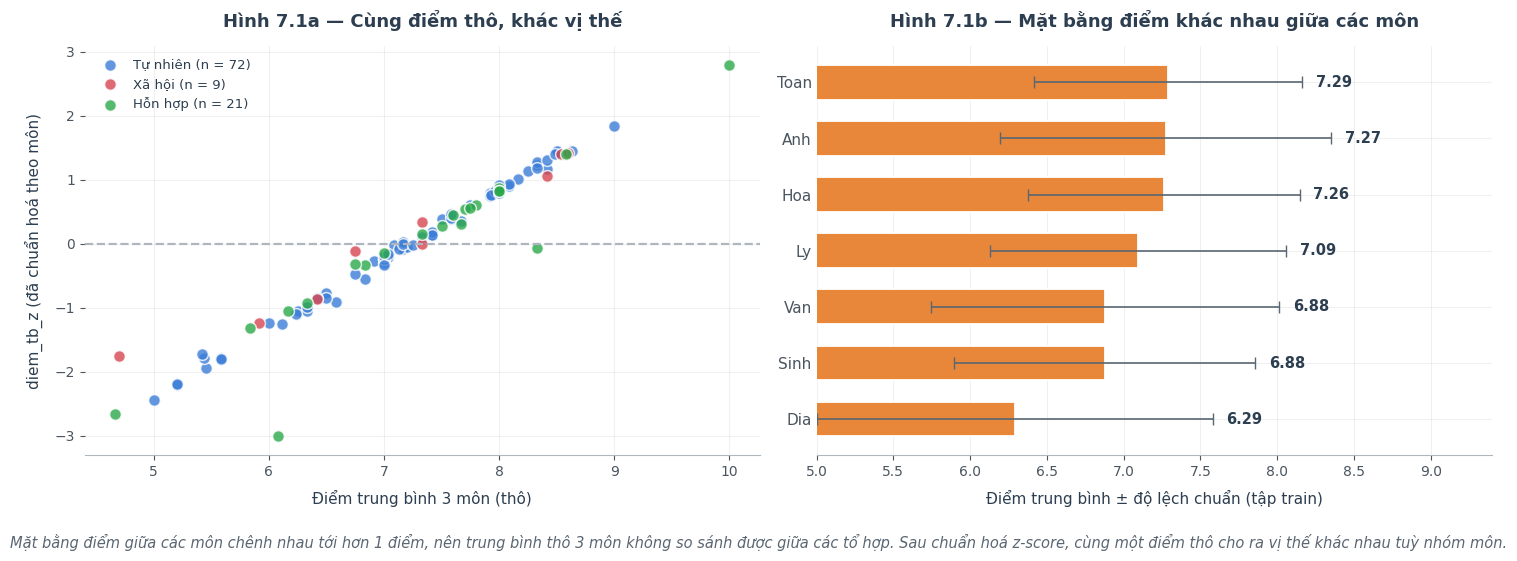

In [4]:
# ═══════════ HÌNH 7.1 — Vì sao phải chuẩn hoá điểm theo môn ═══════════
fig, axes = plt.subplots(1, 2, figsize=(15, 5.3))

nhom_te = df_test_raw["to_hop_thi"].astype(str).str.split().str[0].map(NHOM_TO_HOP).fillna("HH")
tb_tho = df_test_raw[DIEM_COLS].mean(axis=1)

# (a) Điểm thô: cùng con số nhưng khác ý nghĩa
ax = axes[0]
for g, mau in [("TN", C_XANH), ("XH", C_THAT), ("HH", C_GA)]:
    m = nhom_te == g
    if m.sum():
        ax.scatter(tb_tho[m], X_test.loc[m, "diem_tb_z"], s=72, alpha=0.8, color=mau,
                   edgecolor="white", linewidth=1.1, label=f"{TEN_NHOM[g]} (n = {int(m.sum())})")
ax.axhline(0, color=C_XAM, ls="--", lw=1.6)
ax.set_xlabel("Điểm trung bình 3 môn (thô)")
ax.set_ylabel("diem_tb_z (đã chuẩn hoá theo môn)")
ax.set_title("Hình 7.1a — Cùng điểm thô, khác vị thế")
ax.legend(fontsize=9.5); ax.set_axisbelow(True)

# (b) Mặt bằng điểm từng môn khác nhau
ax = axes[1]
co_du = [c for c in DIEM_COLS if df_train_raw[c].notna().sum() >= 200]
tb = [df_train_raw[c].mean() for c in co_du]
sd = [df_train_raw[c].std() for c in co_du]
thu_tu = np.argsort(tb)
ax.barh(range(len(co_du)), [tb[i] for i in thu_tu], xerr=[sd[i] for i in thu_tu],
        height=0.62, color=C_CAM, edgecolor="white", linewidth=1.3,
        error_kw={"ecolor": "#5A6672", "capsize": 4, "lw": 1.2})
for i, k in enumerate(thu_tu):
    ax.text(tb[k] + sd[k] + 0.09, i, f"{tb[k]:.2f}", va="center",
            fontsize=10.5, fontweight="bold", color=C_DAM)
ax.set_yticks(range(len(co_du)))
ax.set_yticklabels([co_du[i].replace("diem_", "") for i in thu_tu], fontsize=11)
ax.set_xlabel("Điểm trung bình ± độ lệch chuẩn (tập train)"); ax.set_xlim(5, 9.4)
ax.set_title("Hình 7.1b — Mặt bằng điểm khác nhau giữa các môn")
ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_7_1_chuan_hoa_diem.png",
    "Mặt bằng điểm giữa các môn chênh nhau tới hơn 1 điểm, nên trung bình thô 3 môn không so sánh "
    "được giữa các tổ hợp. Sau chuẩn hoá z-score, cùng một điểm thô cho ra vị thế khác nhau tuỳ nhóm môn.")
plt.show()

## 2. Nhãn và kiểm tra rò rỉ

Đây là phần quan trọng nhất của giai đoạn này: **chứng minh không còn đặc trưng nào suy ra được từ nhãn**.

In [5]:
ma_sap_xep = sorted(TEN_TO_MA.values())
label_to_idx = {int(m): i for i, m in enumerate(ma_sap_xep)}
idx_to_label = {i: int(m) for i, m in enumerate(ma_sap_xep)}

y_train_nganh = df_train_raw["ma_nganh"].astype(int).map(label_to_idx)
y_test_nganh  = df_test_raw["ma_nganh"].astype(int).map(label_to_idx)
y_train_khoi  = df_train_raw["ma_khoi_nganh"].astype(int)
y_test_khoi   = df_test_raw["ma_nganh"].astype(int).map(NGANH_TO_KHOI)
w_train = df_train_raw["sample_weight"].astype(float)
is_real = df_train_raw["is_real"].astype(int)

# Ma trận thuộc khối (39 × 7) — dùng cho cơ chế nhân xác suất ở Giai đoạn 8
M_nganh_khoi = np.zeros((39, 7), dtype=int)
for ma, i in label_to_idx.items():
    M_nganh_khoi[i, NGANH_TO_KHOI[ma]] = 1
assert (M_nganh_khoi.sum(axis=1) == 1).all()

print("KIỂM TRA RÒ RỈ NHÃN")
print("─" * 74)

# (1) Không có cột nào liên quan tới khối / ngành
xau = [c for c in X_train.columns if "khoi" in c.lower() or "nganh" in c.lower()]
assert not xau, f"Đặc trưng còn cột liên quan tới khối/ngành: {xau}"
print("  ✔ Không có cột nào mang thông tin khối ngành trong bộ đặc trưng")

# (2) Không đặc trưng nào XÁC ĐỊNH ĐƯỢC khối trên toàn bộ dòng.
#     Lưu ý: đặc trưng hiếm nhưng dự báo tốt KHÔNG phải rò rỉ — đó là tín hiệu thật,
#     vì nó là dữ liệu thí sinh khai chứ không suy ra từ nhãn.
xau = []
for c in X_train.columns:
    v = X_train[c].fillna(-999)
    if 2 <= v.nunique() <= 12:
        ct = pd.crosstab(v, y_train_khoi)
        if ct.gt(0).sum(axis=1).eq(1).all():
            xau.append(c)
assert not xau, f"Đặc trưng xác định hoàn toàn khối ngành (rò rỉ): {xau}"
print("  ✔ Không đặc trưng nào xác định hoàn toàn khối ngành")

# (3) Sức dự báo của từng đặc trưng đơn lẻ — chỉ để tham khảo
cd = []
for c in X_train.columns:
    v = X_train[c].fillna(-999)
    if 2 <= v.nunique() <= 12:
        cd.append((c, pd.crosstab(v, y_train_khoi).max(axis=1).sum() / len(v)))
cd.sort(key=lambda t: -t[1])
mốc = y_train_khoi.value_counts(normalize=True).max()
print(f"  ✔ Đặc trưng đơn lẻ mạnh nhất chỉ dự báo đúng khối {cd[0][1]:.1%} "
      f"(đoán theo lớp đông nhất đã được {mốc:.1%})")

# (4) Không trùng dòng giữa train và test
trung = (set(map(tuple, X_train.round(4).fillna(-999).values))
         & set(map(tuple, X_test.round(4).fillna(-999).values)))
print(f"  ✔ Số dòng trùng giữa train và test: {len(trung)}")

assert y_train_nganh.nunique() == 39 and y_test_nganh.nunique() == 39
assert (y_train_khoi.values == np.array([NGANH_TO_KHOI[idx_to_label[i]] for i in y_train_nganh])).all()
print("  ✔ Nhãn hợp lệ: đủ 39 ngành và 7 khối ở cả train lẫn test")
print("─" * 74)

KIỂM TRA RÒ RỈ NHÃN
──────────────────────────────────────────────────────────────────────────
  ✔ Không có cột nào mang thông tin khối ngành trong bộ đặc trưng


  ✔ Không đặc trưng nào xác định hoàn toàn khối ngành
  ✔ Đặc trưng đơn lẻ mạnh nhất chỉ dự báo đúng khối 32.9% (đoán theo lớp đông nhất đã được 27.4%)
  ✔ Số dòng trùng giữa train và test: 0
  ✔ Nhãn hợp lệ: đủ 39 ngành và 7 khối ở cả train lẫn test
──────────────────────────────────────────────────────────────────────────


   💾 Đã lưu hình: hinh_7_2_chat_luong_dac_trung.png


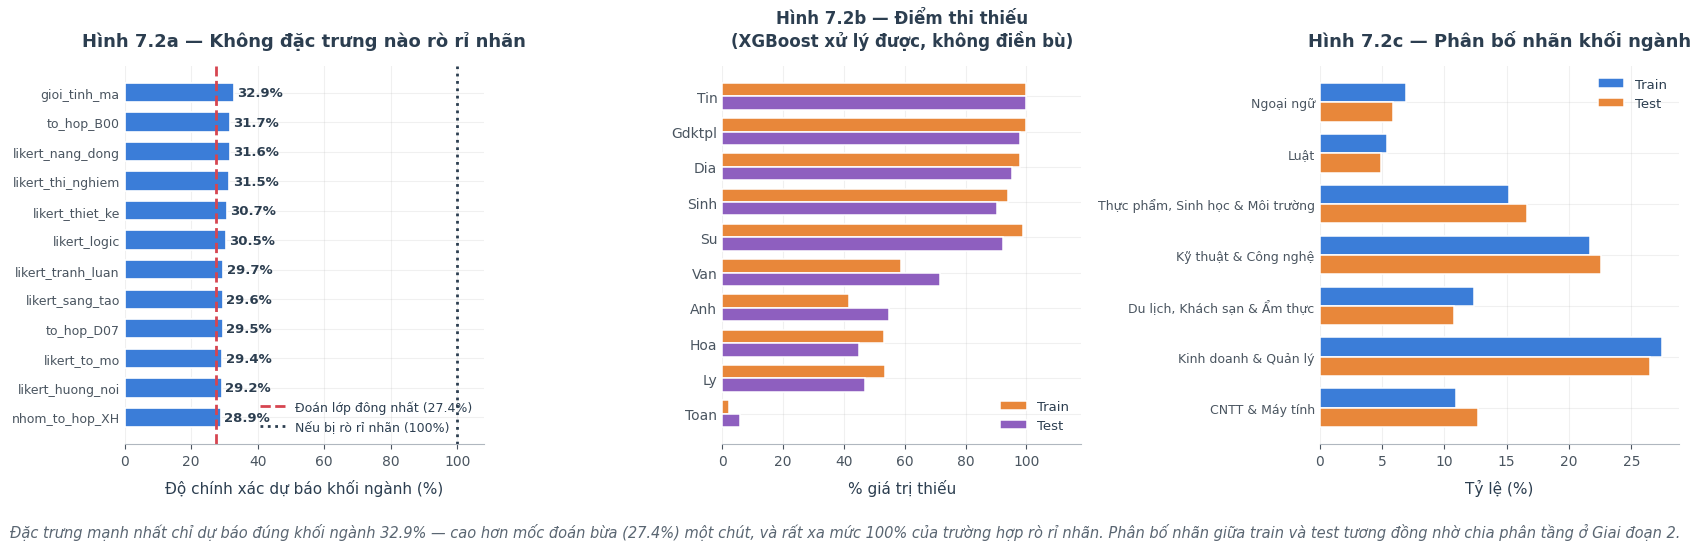

In [6]:
# ═══════════ HÌNH 7.2 — Chất lượng bộ đặc trưng ═══════════
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

# (a) Sức dự báo của đặc trưng đơn lẻ
ax = axes[0]
top = cd[:12][::-1]
ax.barh(range(len(top)), [v * 100 for _, v in top], height=0.66, color=C_XANH,
        edgecolor="white", linewidth=1.2)
ax.axvline(mốc * 100, color=C_THAT, ls="--", lw=2,
           label=f"Đoán lớp đông nhất ({mốc:.1%})")
ax.axvline(100, color=C_DAM, ls=":", lw=2, label="Nếu bị rò rỉ nhãn (100%)")
for i, (_, v) in enumerate(top):
    ax.text(v * 100 + 1, i, f"{v:.1%}", va="center", fontsize=9.5, fontweight="bold")
ax.set_yticks(range(len(top))); ax.set_yticklabels([c for c, _ in top], fontsize=9)
ax.set_xlabel("Độ chính xác dự báo khối ngành (%)"); ax.set_xlim(0, 108)
ax.set_title("Hình 7.2a — Không đặc trưng nào rò rỉ nhãn")
ax.legend(fontsize=9, loc="lower right"); ax.tick_params(axis="y", length=0)
ax.set_axisbelow(True)

# (b) Tỷ lệ giá trị thiếu
ax = axes[1]
nan_tr = df_train_raw[DIEM_COLS].isna().mean() * 100
nan_te = df_test_raw[DIEM_COLS].isna().mean() * 100
y = np.arange(10); h = 0.38
ax.barh(y + h/2, nan_tr.values, h, label="Train", color=C_CAM, edgecolor="white", linewidth=1.1)
ax.barh(y - h/2, nan_te.values, h, label="Test", color=C_TIM, edgecolor="white", linewidth=1.1)
ax.set_yticks(y); ax.set_yticklabels([c.replace("diem_", "") for c in DIEM_COLS], fontsize=10)
ax.set_xlabel("% giá trị thiếu"); ax.set_xlim(0, 118)
ax.set_title("Hình 7.2b — Điểm thi thiếu\n(XGBoost xử lý được, không điền bù)", fontsize=12)
ax.legend(fontsize=9.5); ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

# (c) Phân bố nhãn
ax = axes[2]
d_tr = y_train_khoi.value_counts(normalize=True).sort_index() * 100
d_te = pd.Series(y_test_khoi).value_counts(normalize=True).sort_index() * 100
y = np.arange(7); h = 0.38
ax.barh(y + h/2, d_tr.values, h, label="Train", color=C_XANH, edgecolor="white", linewidth=1.1)
ax.barh(y - h/2, d_te.reindex(range(7)).fillna(0).values, h, label="Test", color=C_CAM,
        edgecolor="white", linewidth=1.1)
ax.set_yticks(y); ax.set_yticklabels([TEN_KHOI[i] for i in range(7)], fontsize=9)
ax.set_xlabel("Tỷ lệ (%)")
ax.set_title("Hình 7.2c — Phân bố nhãn khối ngành")
ax.legend(fontsize=9.5); ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_7_2_chat_luong_dac_trung.png",
    f"Đặc trưng mạnh nhất chỉ dự báo đúng khối ngành {cd[0][1]:.1%} — cao hơn mốc đoán bừa "
    f"({mốc:.1%}) một chút, và rất xa mức 100% của trường hợp rò rỉ nhãn. "
    "Phân bố nhãn giữa train và test tương đồng nhờ chia phân tầng ở Giai đoạn 2.")
plt.show()

In [7]:
# --- Xuất file ----------------------------------------------------------------
X_train.to_csv(OUTPUT_DIR / "X_train.csv", index=False)
X_test.to_csv(OUTPUT_DIR / "X_test.csv", index=False)
y_train_nganh.to_csv(OUTPUT_DIR / "y_train_nganh.csv", index=False, header=["target_nganh"])
y_test_nganh.to_csv(OUTPUT_DIR / "y_test_nganh.csv", index=False, header=["target_nganh"])
y_train_khoi.to_csv(OUTPUT_DIR / "y_train_khoi.csv", index=False, header=["target_khoi"])
y_test_khoi.to_csv(OUTPUT_DIR / "y_test_khoi.csv", index=False, header=["target_khoi"])
w_train.to_csv(OUTPUT_DIR / "w_train.csv", index=False, header=["sample_weight"])
is_real.to_csv(OUTPUT_DIR / "is_real_train.csv", index=False, header=["is_real"])
np.save(OUTPUT_DIR / "M_nganh_khoi.npy", M_nganh_khoi)

json.dump({"features": list(X_train.columns), "n_features": int(X_train.shape[1]),
           "likert_cols": LIKERT_COLS, "diem_cols": DIEM_COLS, "to_hop_list": TO_HOP_LIST,
           "nhom_to_hop": NHOM_TO_HOP,
           "ghi_chu": "Tầng 1 và Tầng 2 dùng CHUNG bộ đặc trưng này. "
                      "Không có cột nào suy ra được từ nhãn."},
          open(OUTPUT_DIR / "feature_names.json", "w", encoding="utf-8"), ensure_ascii=False, indent=2)
json.dump({"label_to_idx": {str(k): v for k, v in label_to_idx.items()},
           "idx_to_label": {str(k): v for k, v in idx_to_label.items()},
           "idx_to_name": {str(i): MA_TO_TEN[m] for i, m in idx_to_label.items()},
           "idx_to_khoi": {str(i): NGANH_TO_KHOI[m] for i, m in idx_to_label.items()},
           "khoi_to_name": {str(k): v for k, v in TEN_KHOI.items()},
           "n_classes": 39, "n_khoi": 7},
          open(OUTPUT_DIR / "label_encoder_mapping.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)
json.dump(diem_stats, open(OUTPUT_DIR / "diem_zscore_stats.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)

print("═" * 68)
print("  TÓM TẮT GIAI ĐOẠN 7")
print("═" * 68)
print(f"  Số đặc trưng                  {X_train.shape[1]:>10}")
print(f"  X_train                       {str(X_train.shape):>10}")
print(f"  X_test                        {str(X_test.shape):>10}")
print(f"  Số lớp — ngành / khối         {'39 / 7':>10}")
print(f"  Đặc trưng rò rỉ nhãn          {0:>10}")
print(f"  Dòng trùng train ∩ test       {len(trung):>10}")
print("═" * 68)
print(f"\n  Tệp xuất: X_train, X_test, y_*_nganh, y_*_khoi, w_train, is_real_train,")
print(f"            M_nganh_khoi.npy, feature_names.json, label_encoder_mapping.json")
print(f"  Hình đã lưu tại: {OUTPUT_DIR}/")

════════════════════════════════════════════════════════════════════
  TÓM TẮT GIAI ĐOẠN 7
════════════════════════════════════════════════════════════════════
  Số đặc trưng                          43
  X_train                       (14370, 43)
  X_test                         (102, 43)
  Số lớp — ngành / khối             39 / 7
  Đặc trưng rò rỉ nhãn                   0
  Dòng trùng train ∩ test                0
════════════════════════════════════════════════════════════════════

  Tệp xuất: X_train, X_test, y_*_nganh, y_*_khoi, w_train, is_real_train,
            M_nganh_khoi.npy, feature_names.json, label_encoder_mapping.json
  Hình đã lưu tại: ../data/processed/07_model_ready/
